In [ ]:
!pip install faiss-cpu optuna datasets evaluate kagglehub

import os
import torch
import pandas as pd
import numpy as np
import faiss
import networkx as nx
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
from torch import nn
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm
import optuna
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 22.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This be

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
from sklearn.utils import shuffle


path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")
fake = pd.read_csv(path + "/Fake.csv")
real = pd.read_csv(path + "/True.csv")

fake['label'] = 1
real['label'] = 0

data = pd.concat([fake, real], axis=0)
data = shuffle(data, random_state=42).drop_duplicates(subset=['text', 'title']).reset_index(drop=True)

In [ ]:
print(data.duplicated(subset = ['text'] ).sum())
print(data.duplicated(subset = ['title'] ).sum())

459
376


In [ ]:
data = data.drop_duplicates(subset=['title']).reset_index(drop = True)
data = data.drop_duplicates(subset=['text']).reset_index(drop = True)

In [ ]:
len(data)

38270

In [ ]:
n_per_class = 5000
df_fake = data[data['label'] == 1].sample(n=n_per_class, random_state=42)
df_real = data[data['label'] == 0].sample(n=n_per_class, random_state=42)
data = pd.concat([df_fake, df_real]).sample(frac=1, random_state=42).reset_index(drop=True)
data.to_csv('data_bert.csv', index=False)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

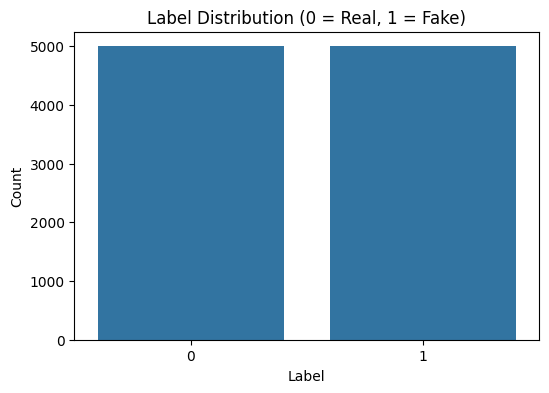

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=data)
plt.title('Label Distribution (0 = Real, 1 = Fake)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

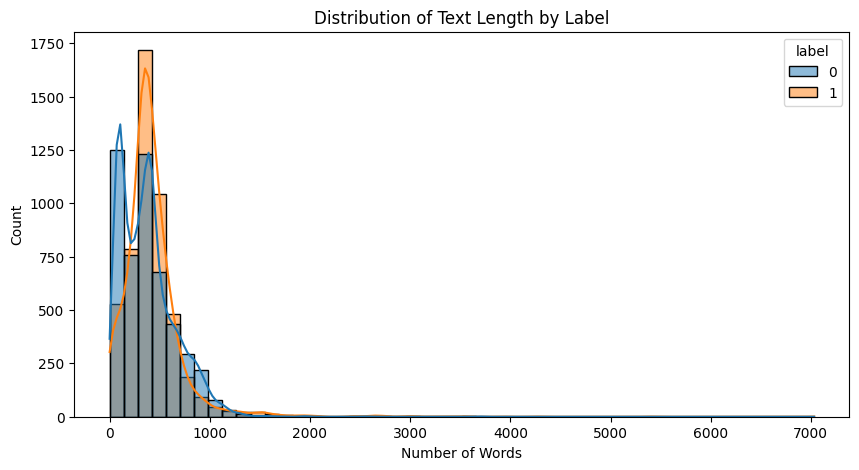

In [ ]:
data['text_length'] = data['text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 5))
sns.histplot(data=data, x='text_length', hue='label', bins=50, kde=True)
plt.title('Distribution of Text Length by Label')
plt.xlabel('Number of Words')
plt.show()

In [ ]:
import nltk
from nltk.corpus import stopwords

In [ ]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


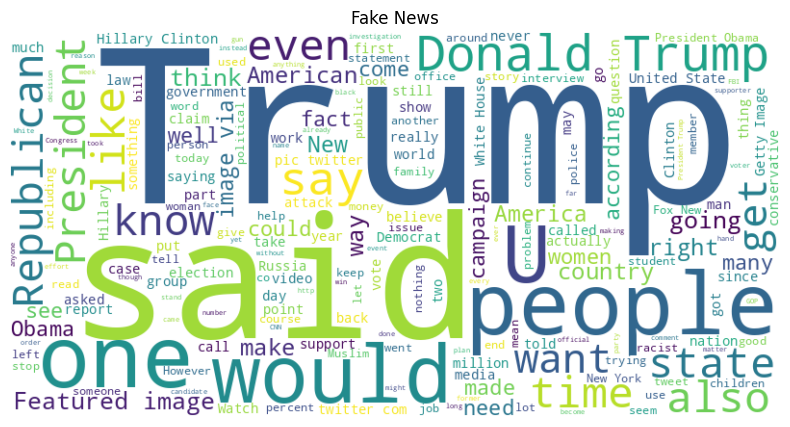

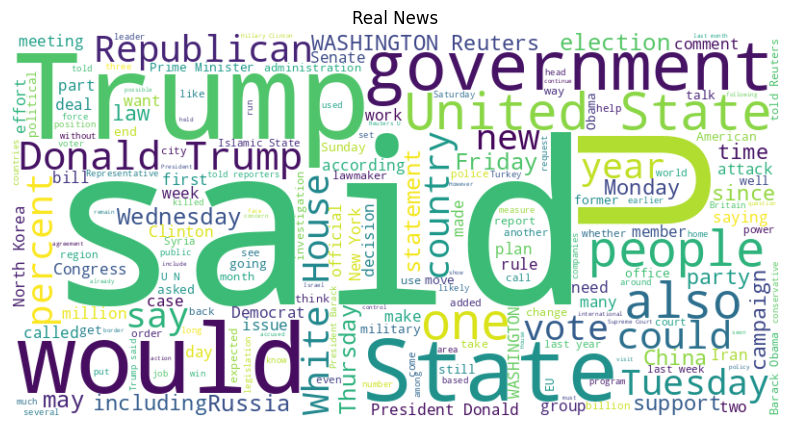

In [ ]:
def generate_wordcloud(label):
    text = " ".join(data[data['label'] == label]['text'])
    wc = WordCloud(width=800, height=400, stopwords=stop_words, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title("Fake News" if label == 1 else "Real News")
    plt.show()

generate_wordcloud(1)
print("\n")
generate_wordcloud(0)

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(data['title'].tolist(), convert_to_numpy=True, device='cuda')
faiss.normalize_L2(embeddings)

index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)

k, threshold = 25, 0.9
D, I = index.search(embeddings, k)
G = nx.Graph()

for i in range(len(data)):
    for j, score in zip(I[i], D[i]):
        if i != j and score >= threshold:
            G.add_edge(i, j)

clusters = list(nx.connected_components(G))
cluster_labels = -1 * np.ones(len(data), dtype=int)

for cluster_id, component in enumerate(clusters):
    for idx in component:
        cluster_labels[idx] = cluster_id

unassigned = np.where(cluster_labels == -1)[0]
for idx in unassigned:
    cluster_labels[idx] = len(clusters)
    clusters.append({idx})

data['cluster'] = cluster_labels

# Split by cluster
train_clusters, test_clusters = train_test_split(data['cluster'].unique(), test_size=0.3, random_state=42)
data['split'] = data['cluster'].apply(lambda x: 'train' if x in train_clusters else 'test')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
model_name = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(texts):
    return tokenizer(texts, padding=True, truncation=True, max_length=512, return_tensors='pt')

class FakeNewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

x_train = data[data['split'] == 'train']['title'].tolist()
y_train = data[data['split'] == 'train']['label'].tolist()
x_test = data[data['split'] == 'test']['title'].tolist()
y_test = data[data['split'] == 'test']['label'].tolist()

train_dataset = FakeNewsDataset(tokenize(x_train), y_train)
test_dataset = FakeNewsDataset(tokenize(x_test), y_test)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
class FakeNewsClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.classifier = nn.Sequential(
            nn.Linear(self.bert.config.hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 2)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(outputs.last_hidden_state[:, 0])

def train(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    preds, truths = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask)
            preds += torch.argmax(outputs, axis=1).cpu().tolist()
            truths += labels.cpu().tolist()

    print("Classification Report:\n", classification_report(truths, preds))
    return accuracy_score(truths, preds)


In [ ]:
def objective(trial):
    lr = trial.suggest_float('lr', 1e-5, 5e-5, log=True)
    bs = trial.suggest_categorical('bs', [16, 32])
    epochs = trial.suggest_int('epochs', 3, 5)

    model = FakeNewsClassifier().to(device)
    optimizer = AdamW(model.parameters(), lr=lr)
    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=bs)

    scheduler = get_linear_schedule_with_warmup(optimizer, 0, len(train_loader) * epochs)
    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        train(model, train_loader, optimizer, scheduler, criterion)

    acc = evaluate(model, test_loader)
    trial.set_user_attr('model_state_dict', model.state_dict())
    return acc

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

[I 2025-05-01 08:58:54,917] A new study created in memory with name: no-name-f9c67a8e-af51-462a-9920-483108b4480d
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

[I 2025-05-01 09:01:44,422] Trial 0 finished with value: 0.978 and parameters: {'lr': 3.235075401108014e-05, 'bs': 32, 'epochs': 5}. Best is trial 0 with value: 0.978.


Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      1503
           1       0.98      0.98      0.98      1497

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



[I 2025-05-01 09:04:33,090] Trial 1 finished with value: 0.9823333333333333 and parameters: {'lr': 4.0838518596513115e-05, 'bs': 32, 'epochs': 5}. Best is trial 1 with value: 0.9823333333333333.


...

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      1503
           1       0.98      0.98      0.98      1497

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



[I 2025-05-01 09:20:39,223] Trial 8 finished with value: 0.9776666666666667 and parameters: {'lr': 1.3006621748100738e-05, 'bs': 16, 'epochs': 4}. Best is trial 1 with value: 0.9823333333333333.


Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      1503
           1       0.98      0.98      0.98      1497

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



[I 2025-05-01 09:22:22,530] Trial 9 finished with value: 0.98 and parameters: {'lr': 2.5316710023749535e-05, 'bs': 32, 'epochs': 3}. Best is trial 1 with value: 0.9823333333333333.


Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      1503
           1       0.98      0.98      0.98      1497

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



<ipython-input-11-096e0f2e4be1>:1: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


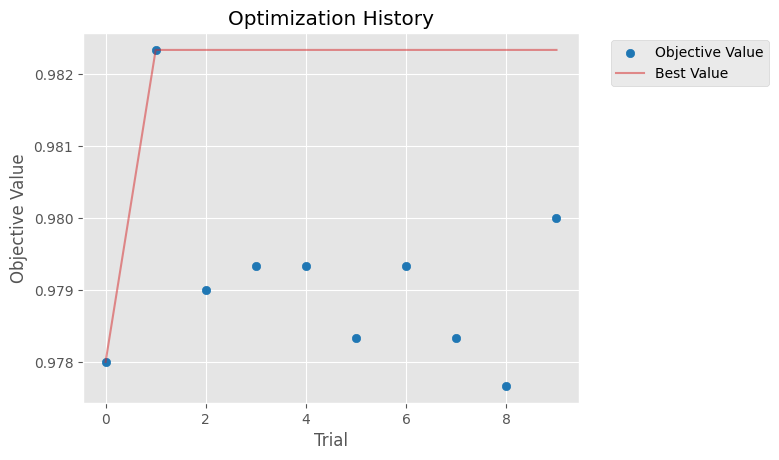

<ipython-input-11-096e0f2e4be1>:5: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


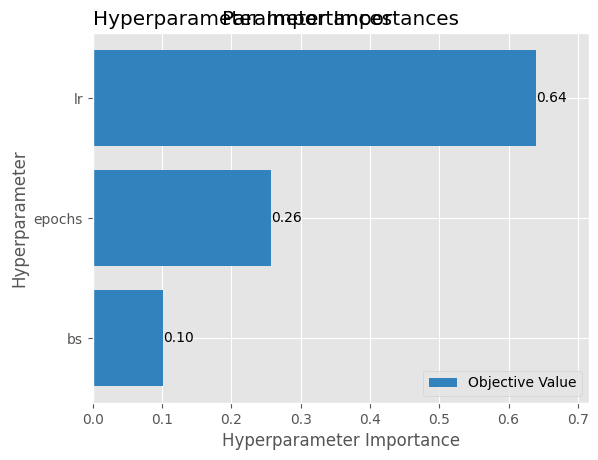

In [ ]:
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optimization History")
plt.show()

optuna.visualization.matplotlib.plot_param_importances(study)
plt.title("Parameter Importances")
plt.show()

In [ ]:
best_model = FakeNewsClassifier().to(device) # Create an instance of the model
best_model.load_state_dict(study.best_trial.user_attrs['model_state_dict']) # Load best model weights
# Save model weights
torch.save(best_model.state_dict(), "best_fakenews_model.pt")

# Save tokenizer
tokenizer.save_pretrained("best_tokenizer/")

('best_tokenizer/tokenizer_config.json',
 'best_tokenizer/special_tokens_map.json',
 'best_tokenizer/vocab.txt',
 'best_tokenizer/added_tokens.json',
 'best_tokenizer/tokenizer.json')

In [ ]:
# # Retrieve best hyperparameters
best_params = study.best_params

# # Recreate model and optimizer with best params
# final_model = FakeNewsClassifier().to(device)
# optimizer = AdamW(final_model.parameters(), lr=best_params['lr'])
train_loader = DataLoader(train_dataset, batch_size=best_params['bs'], shuffle=True)



In [ ]:
train_acc = evaluate(best_model, train_loader)
print(f"Train Accuracy:{train_acc:.4f}")
test_loader = DataLoader(test_dataset, batch_size=best_params['bs'])
test_acc = evaluate(best_model, test_loader)
print(f"Test Accuracy:{test_acc:.4f}")

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3497
           1       1.00      1.00      1.00      3503

    accuracy                           1.00      7000
   macro avg       1.00      1.00      1.00      7000
weighted avg       1.00      1.00      1.00      7000

Train Accuracy:1.0000
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      1503
           1       0.98      0.98      0.98      1497

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000

Test Accuracy:0.9823


In [ ]:
def predict(text):
    final_model.eval()
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = final_model(**inputs)
        prediction = torch.argmax(outputs, dim=1).item()
    return "Fake" if prediction == 1 else "Real"

print(predict("Breaking: The president signs new healthcare reform bill"))

Fake
